# 01 — Black-Scholes-Merton: Pricing, Greeks & Implied Volatility

The Black-Scholes-Merton (BSM) model is the foundation of options theory. Despite its well-known limitations — constant vol, no jumps, continuous hedging — it remains the market standard for quoting and communicating option prices via **implied volatility**.

This notebook walks through:
1. Pricing calls and puts
2. Computing and interpreting the Greeks
3. Inverting BSM to extract implied vol from market prices
4. Sanity checks: put-call parity and boundary conditions

> **Key point**: BSM is not a model we *believe in* — it is a *translation device*. Implied vol is simply the vol parameter that makes BSM match the market price. The structure of implied vol across strikes and expiries (the *surface*) is where the real information lives.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "..")

from src.bsm import BSM

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11


## 1. Pricing a Vanilla Option

We price a 6-month ATM call on a hypothetical equity with:
- Spot S = 100, Strike K = 100 (ATM)
- Risk-free rate r = 5%, dividend yield q = 1%
- Implied vol σ = 20%


In [2]:
S, K, T, r, q, sigma = 100.0, 100.0, 0.5, 0.05, 0.01, 0.20

call_price = BSM.price(S, K, T, r, q, sigma, "call")
put_price  = BSM.price(S, K, T, r, q, sigma, "put")

print(f"Call price: {call_price:.4f}")
print(f"Put price:  {put_price:.4f}")

# Put-call parity check: C - P = S*exp(-qT) - K*exp(-rT)
parity_lhs = call_price - put_price
parity_rhs = S * np.exp(-q * T) - K * np.exp(-r * T)
print("\nPut-call parity check:")
print(f"  C - P  = {parity_lhs:.6f}")
print(f"  S*exp(-qT) - K*exp(-rT) = {parity_rhs:.6f}")
print(f"  Error  = {abs(parity_lhs - parity_rhs):.2e}")


Call price: 6.5940
Put price:  4.6238

Put-call parity check:
  C - P  = 1.970257
  S*exp(-qT) - K*exp(-rT) = 1.970257
  Error  = 7.11e-15


## 2. The Greeks

Greeks measure sensitivity of the option price to various inputs. They are the primary language of options risk management.

| Greek | Sensitivity to | Sign (long call) |
|-------|---------------|------------------|
| Delta | Spot price | Positive (0 to 1) |
| Gamma | Delta (2nd order spot) | Positive |
| Vega  | Volatility | Positive |
| Theta | Time | Negative (time decay) |
| Rho   | Risk-free rate | Positive |


In [3]:
result = BSM.greeks(S, K, T, r, q, sigma, "call")
print(result)

print("\nInterpretation:")
print(f"  A 1% rise in spot -> call changes by ~{result.delta:.3f} (delta)")
print(f"  A 1% rise in vol  -> call changes by ~{result.vega:.4f} (vega per 1% vol)")
print(f"  Each calendar day -> call loses ~{abs(result.theta):.4f} (theta)")


BSMResult(
  price=6.5940,
  delta=0.5811,
  gamma=0.027444,
  vega=0.2744,
  theta=-0.0205,
  rho=0.2576
)

Interpretation:
  A 1% rise in spot -> call changes by ~0.581 (delta)
  A 1% rise in vol  -> call changes by ~0.2744 (vega per 1% vol)
  Each calendar day -> call loses ~0.0205 (theta)


## 3. Greeks Across Strikes

How do the Greeks behave as we move across moneyness? This is important for understanding hedging costs and risk profiles.


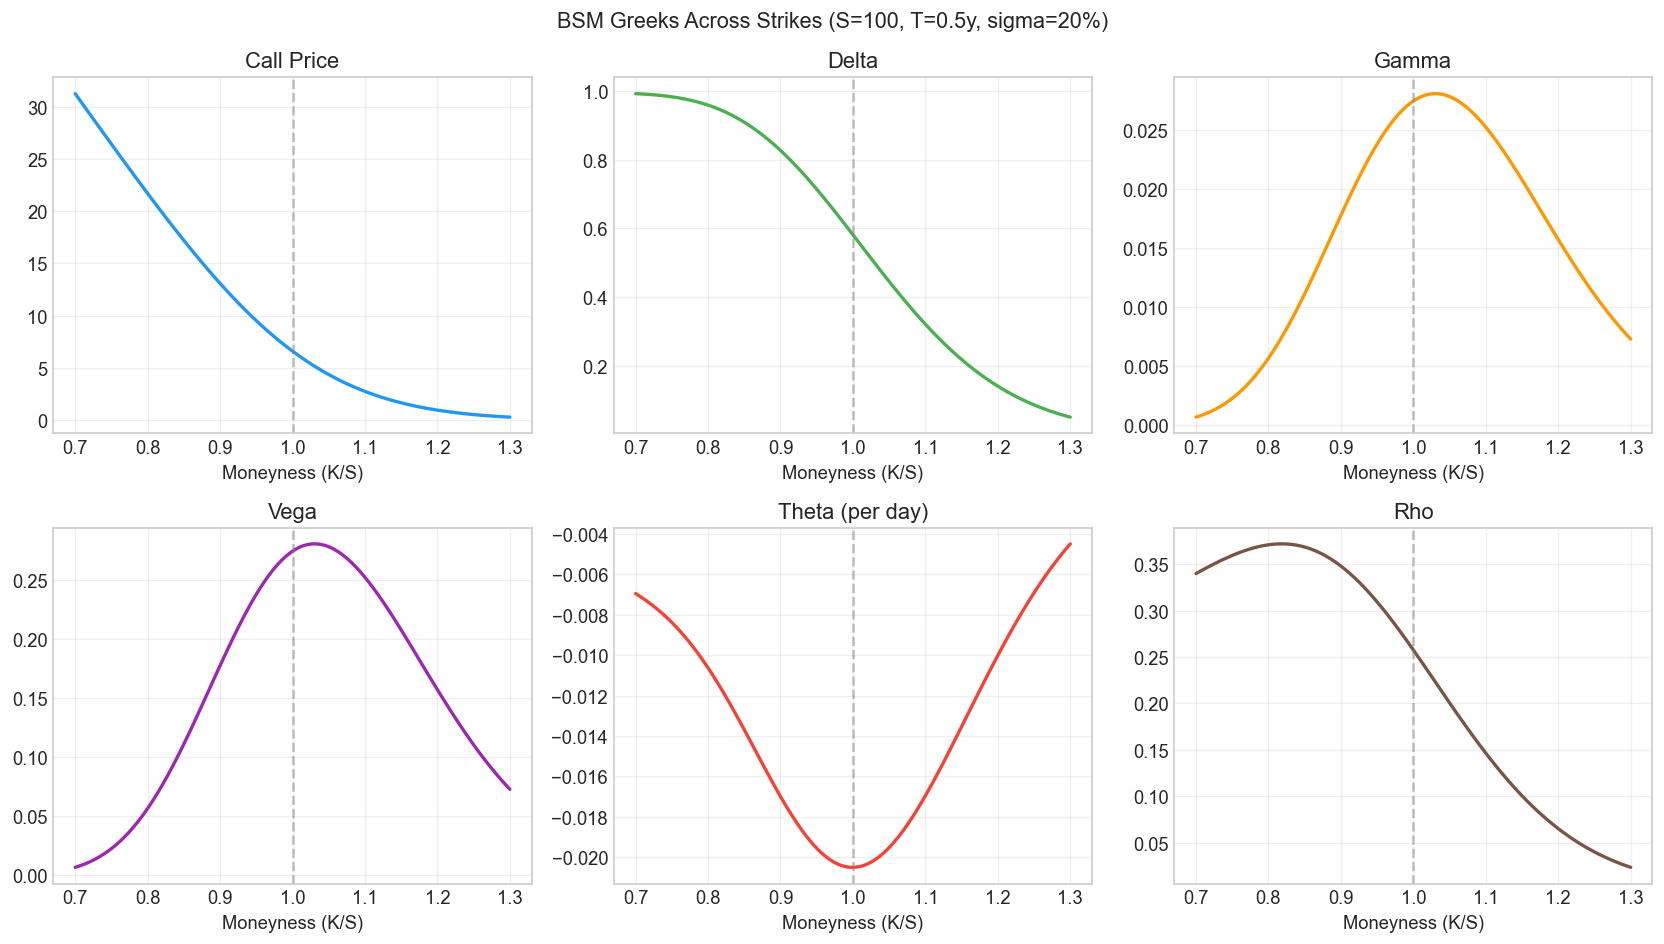

In [4]:
strikes = np.linspace(70, 130, 100)
greeks_data = [BSM.greeks(S, K_, T, r, q, sigma, "call") for K_ in strikes]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("BSM Greeks Across Strikes (S=100, T=0.5y, sigma=20%)", fontsize=13)

moneyness = strikes / S
metrics = [("price", "Call Price", "#2196F3"),
           ("delta", "Delta", "#4CAF50"),
           ("gamma", "Gamma", "#FF9800"),
           ("vega",  "Vega",  "#9C27B0"),
           ("theta", "Theta (per day)", "#F44336"),
           ("rho",   "Rho",   "#795548")]

for ax, (attr, label, color) in zip(axes.flat, metrics):
    values = [getattr(g, attr) for g in greeks_data]
    ax.plot(moneyness, values, color=color, lw=2)
    ax.axvline(1.0, color="grey", linestyle="--", alpha=0.5)
    ax.set_xlabel("Moneyness (K/S)")
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/01_greeks_across_strikes.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Implied Volatility Extraction

Given a market price, we invert BSM to recover the implied vol using Brent's method. This is a standard root-finding problem: find sigma such that BSM(sigma) = market_price.

**What to watch for:** the implied vol that comes out depends on your assumed r and q. In practice, traders often use at-the-money options to calibrate r and q first, then solve for IV on other strikes. Here we assume r and q are known.


True sigma: 25.00%
Market price: 7.9681
Recovered IV: 25.00%
Error: 1.48e-10


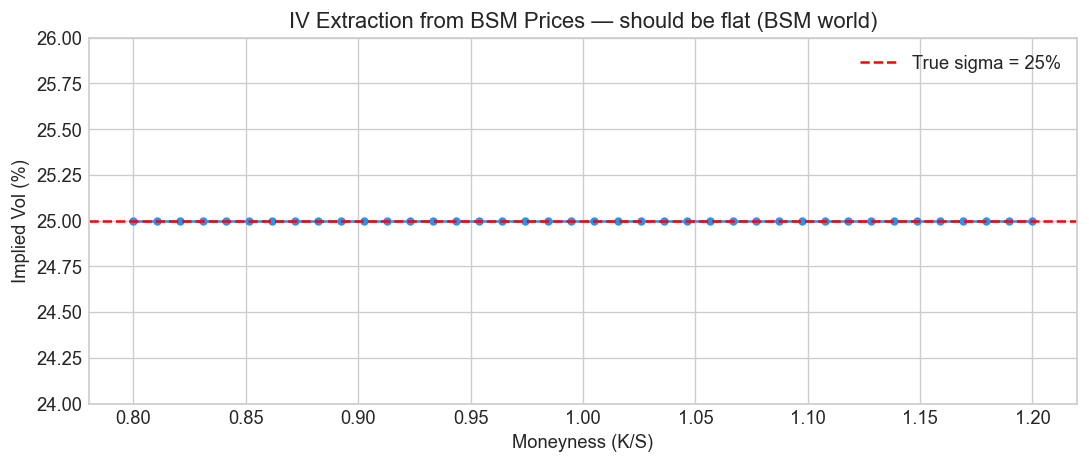


Note: In real markets the smile is NOT flat — that is the subject of notebook 02.


In [ ]:
# Simulate a market price with a "true" vol of 25%
true_sigma = 0.25
market_price = BSM.price(S, K, T, r, q, true_sigma, "call")
print(f"True sigma: {true_sigma:.2%}")
print(f"Market price: {market_price:.4f}")

recovered_iv = BSM.implied_vol(market_price, S, K, T, r, q, "call")
print(f"Recovered IV: {recovered_iv:.2%}")
print(f"Error: {abs(recovered_iv - true_sigma):.2e}")

# Show IV as a function of strike (with constant true vol — should be flat)
strikes_iv = np.linspace(80, 120, 40)
market_prices = [BSM.price(S, K_, T, r, q, true_sigma, "call") for K_ in strikes_iv]
implied_vols  = [BSM.implied_vol(p, S, K_, T, r, q, "call") for p, K_ in zip(market_prices, strikes_iv)]

plt.figure(figsize=(9, 4))
plt.plot(strikes_iv / S, np.array(implied_vols) * 100, "o-", color="#2196F3", ms=4)
plt.axhline(true_sigma * 100, color="red", linestyle="--", label=f"True sigma = {true_sigma:.0%}")
plt.xlabel("Moneyness (K/S)")
plt.ylabel("Implied Vol (%)")
plt.title("IV Extraction from BSM Prices — should be flat (BSM world)")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/01_iv_roundtrip.png", dpi=150, bbox_inches="tight")
plt.ylim(24, 26)
plt.show()

print("\nNote: In real markets the smile is NOT flat — that is the subject of notebook 02.")


## Summary

- BSM gives us a consistent framework for pricing and hedging, even though its assumptions are violated in practice.
- The Greeks quantify option sensitivities and are the primary language of risk management.
- Implied vol is a *market quote in disguise* — the real object of interest is the surface sigma(K,T), not the flat BSM world.

**Next:** Notebook 02 builds the implied vol surface from real SPY options data.
